# Import libaries

---



In [1]:
import tarfile
import os
import pickle
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
from torch import nn
import torchvision
from torchvision.datasets.utils import download_url
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CIFAR-10 dataset

In [2]:
# dowload the dataset
dataset_url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
download_url(dataset_url, '.')

# extract file CIFAR-10 dataset
with tarfile.open('cifar-10-python.tar.gz', 'r:gz') as tar:
    tar.extractall(path='./data')

data_dir = './data/cifar-10-batches-py'
# print name folders
print(os.listdir(data_dir))

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


['batches.meta', 'readme.html', 'data_batch_1', 'data_batch_4', 'data_batch_3', 'data_batch_2', 'test_batch', 'data_batch_5']


In [3]:
def load_batch(file):
  with open(file, 'rb') as f:
    dict = pickle.load(f, encoding='bytes')
    data = dict[b'data']
    labels = dict[b'labels']
    return data, labels

# load and combine training batches
X_train = []
y_train = []

for i in range(1, 6):
    batch_file = os.path.join(data_dir, f'data_batch_{i}')
    data, labels = load_batch(batch_file)
    X_train.append(data)
    y_train.extend(labels)

# combine into a single numpy array
X_train = np.concatenate(X_train)
y_train = np.array(y_train)

# load test batch
test_file = os.path.join(data_dir, 'test_batch')
X_test, y_test = load_batch(test_file)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)


# Split train-valid-test and preprocessing

In [4]:
import numpy as np
import pickle, os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from PIL import Image

# Reshape and ensure uint8 format (transforms expect images as uint8 before ToTensor)
X_train = X_train.reshape(-1, 3, 32, 32).astype('uint8')
X_test = X_test.reshape(-1, 3, 32, 32).astype('uint8')

# Split validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.9, random_state=42)

# Define mean and std for CIFAR-10 normalization
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# Define transforms
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Custom Dataset class
class CIFARDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        img = img.astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

# Create datasets
train_dataset = CIFARDataset(X_train, y_train, transform=train_transform)
val_dataset   = CIFARDataset(X_val, y_val, transform=test_transform)
test_dataset  = CIFARDataset(X_test, y_test, transform=test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Create model


In [5]:
def create_MLP_model(dropout_rate = 0.3):
  model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(3072, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    nn.Linear(256, 10)
  )
  return model


def create_CNN_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # CNN-1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 32 x 16 x 16

    # CNN-2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 64 x 8 x 8

    # CNN-3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 128 x 4 x 4

    nn.Flatten(),

    # Dense layer
    nn.Linear(128*4*4, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

# Training model

In [6]:
def train_model(model, train_dataset, val_dataset, num_epochs=50, batch_size=128, learning_rate=0.001):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  loss_fn = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

  train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size * 2)

  history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
  for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      train_loss += loss.item()

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      preds = torch.argmax(y_pred, dim=1)
      train_correct += (preds == y_batch).sum().item()
      train_total += y_batch.size(0)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.inference_mode():
      for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        val_loss += loss.item()

        preds = torch.argmax(y_pred, dim=1)
        val_correct += (preds == y_batch).sum().item()
        val_total += y_batch.size(0)

    scheduler.step()

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total

    history['accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, "
          f"Val Loss: {val_loss/len(val_loader):.4f}, "
          f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")
  return history

# Evaluate model and plot learning curve, confusion matrix

In [7]:
def plot_curve(history):
  epochs = range(1, len(history["accuracy"]) + 1)

  plt.figure(figsize = (12, 5))

  # accuracy plot
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["accuracy"], label = "Train Accuracy")
  plt.plot(epochs, history["val_accuracy"], label = "Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.title("Accuracy Curve")
  plt.legend()

  # loss plot
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history["loss"], label = "Train Loss")
  plt.plot(epochs, history["val_loss"], label = "Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend()

  plt.show()

In [8]:
def evaluate_model(model, test_dataset, batch_size = 128):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device).eval()

  loss_fn = nn.CrossEntropyLoss()
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  total_loss = 0
  test_correct = 0
  test_total = 0

  with torch.inference_mode():
    for X_batch, y_batch in test_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      y_pred = model(X_batch)
      total_loss += loss_fn(y_pred, y_batch).item()

      preds = y_pred.argmax(dim = 1)
      test_correct += (preds == y_batch).sum().item()
      test_total += y_batch.size(0)

  loss = total_loss / len(test_loader)
  acc = test_correct / test_total
  return loss, acc

In [9]:
def plot_matrix(model, test_dataset, batch_size = 128):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device).eval()
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  y_true = []
  y_pred = []

  with torch.inference_mode():
    for X_batch, y_batch in test_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred_batch = model(X_batch)
      preds = y_pred_batch.argmax(dim = 1)
      y_true.extend(y_batch.cpu().numpy())
      y_pred.extend(preds.cpu().numpy())

  cm = confusion_matrix(y_true, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.show()

Epoch 1/30 | Train Loss: 1.8613, Val Loss: 1.6517, Train Acc: 0.3231, Val Acc: 0.4070
Epoch 2/30 | Train Loss: 1.7047, Val Loss: 1.5527, Train Acc: 0.3805, Val Acc: 0.4350
Epoch 3/30 | Train Loss: 1.6357, Val Loss: 1.5074, Train Acc: 0.4072, Val Acc: 0.4538
Epoch 4/30 | Train Loss: 1.6016, Val Loss: 1.4636, Train Acc: 0.4193, Val Acc: 0.4680
Epoch 5/30 | Train Loss: 1.5777, Val Loss: 1.4394, Train Acc: 0.4293, Val Acc: 0.4856
Epoch 6/30 | Train Loss: 1.5524, Val Loss: 1.4326, Train Acc: 0.4405, Val Acc: 0.4854
Epoch 7/30 | Train Loss: 1.5393, Val Loss: 1.4011, Train Acc: 0.4444, Val Acc: 0.4936
Epoch 8/30 | Train Loss: 1.5184, Val Loss: 1.3645, Train Acc: 0.4525, Val Acc: 0.5058
Epoch 9/30 | Train Loss: 1.5021, Val Loss: 1.3746, Train Acc: 0.4536, Val Acc: 0.4958
Epoch 10/30 | Train Loss: 1.4891, Val Loss: 1.3593, Train Acc: 0.4619, Val Acc: 0.5078
Epoch 11/30 | Train Loss: 1.4789, Val Loss: 1.3399, Train Acc: 0.4675, Val Acc: 0.5154
Epoch 12/30 | Train Loss: 1.4651, Val Loss: 1.3304, 

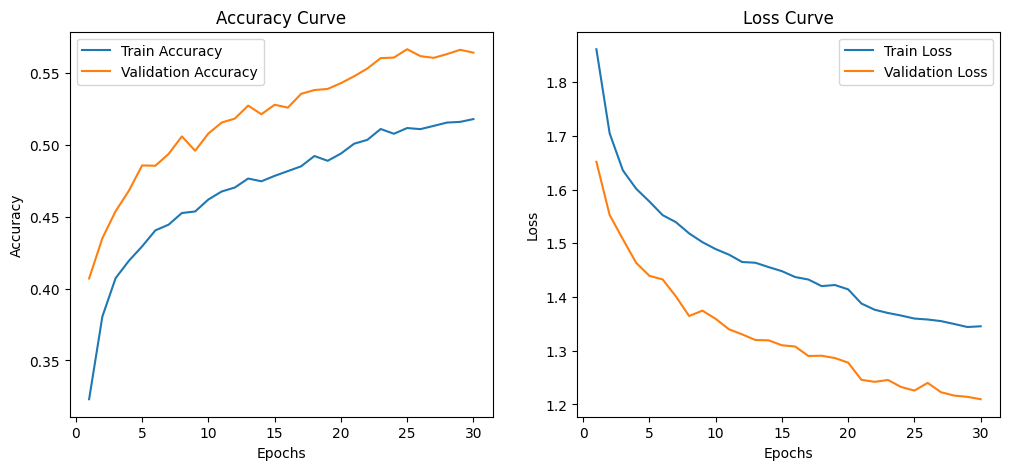

Test Loss: 1.2027, Test Accuracy: 0.5678


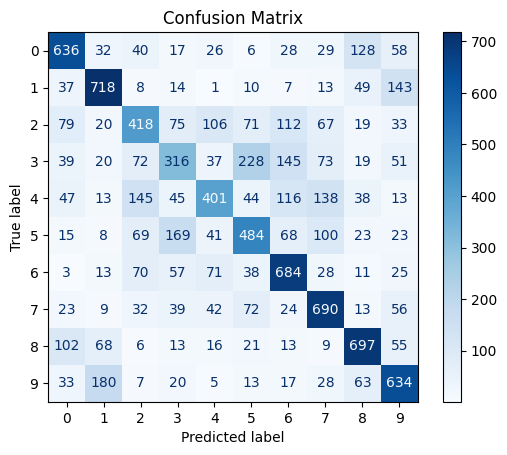

In [10]:
model = create_MLP_model()
history = train_model(model, train_dataset, val_dataset, num_epochs = 30, batch_size = 128, learning_rate = 0.001)
plot_curve(history)
test_loss, test_acc = evaluate_model(model, test_dataset, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

plot_matrix(model, test_dataset)

Epoch 1/30 | Train Loss: 1.6387, Val Loss: 1.2988, Train Acc: 0.3961, Val Acc: 0.5212
Epoch 2/30 | Train Loss: 1.2214, Val Loss: 1.0775, Train Acc: 0.5621, Val Acc: 0.6156
Epoch 3/30 | Train Loss: 1.0292, Val Loss: 0.8626, Train Acc: 0.6409, Val Acc: 0.6902
Epoch 4/30 | Train Loss: 0.9096, Val Loss: 0.7787, Train Acc: 0.6785, Val Acc: 0.7258
Epoch 5/30 | Train Loss: 0.8289, Val Loss: 0.7516, Train Acc: 0.7112, Val Acc: 0.7384
Epoch 6/30 | Train Loss: 0.7703, Val Loss: 0.7263, Train Acc: 0.7302, Val Acc: 0.7414
Epoch 7/30 | Train Loss: 0.7173, Val Loss: 0.6662, Train Acc: 0.7526, Val Acc: 0.7756
Epoch 8/30 | Train Loss: 0.6725, Val Loss: 0.6892, Train Acc: 0.7664, Val Acc: 0.7634
Epoch 9/30 | Train Loss: 0.6520, Val Loss: 0.6100, Train Acc: 0.7734, Val Acc: 0.7910
Epoch 10/30 | Train Loss: 0.6130, Val Loss: 0.6268, Train Acc: 0.7868, Val Acc: 0.7860
Epoch 11/30 | Train Loss: 0.5913, Val Loss: 0.5820, Train Acc: 0.7946, Val Acc: 0.8002
Epoch 12/30 | Train Loss: 0.5674, Val Loss: 0.6044, 

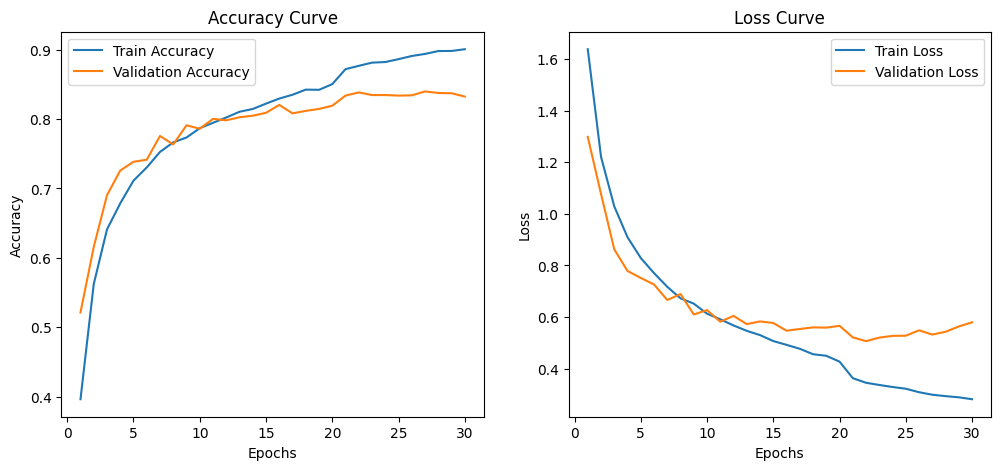

Test Loss: 0.5898, Test Accuracy: 0.8305


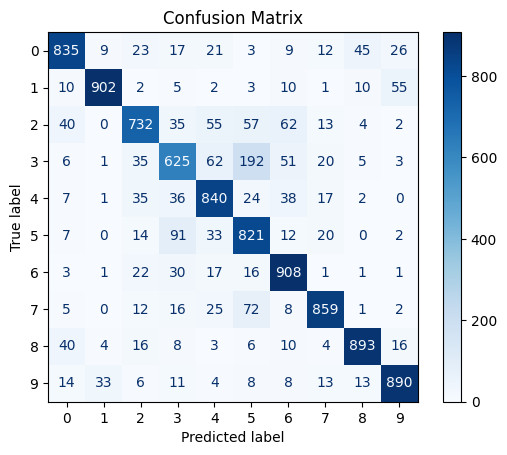

In [11]:
model = create_CNN_model()
history = train_model(model, train_dataset, val_dataset, num_epochs = 30, batch_size = 128, learning_rate = 0.001)
plot_curve(history)
test_loss, test_acc = evaluate_model(model, test_dataset, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

plot_matrix(model, test_dataset)